# Purpose

This notebook generates the schemas used to demonstrate the consensus and advection dynamics in the manuscript (Fig 3, S2).

In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

import sys
sys.path.append('..')
from scripts import basic_components as bcomp, draw

In [2]:
# default values for colorbars
vmin = 0; vmax = 1; cmap = "Reds"

# Generate data for Fig 3 & Fig S2

In [3]:
# Generate data for Fig 3.A, B 
# Demonstrate how consensus and advection evolve on the simple networks.

# Create simple networks with 3 nodes.
adjM_C = np.array([[0, 0, 0],
                  [1, 0, 1],
                  [0, 0, 0]])
adjM_A = np.array([[0, 0, 0],
                  [1, 0, 0],
                  [0, 1, 0]])

G1 = nx.from_numpy_array(adjM_C.T, create_using=nx.DiGraph)
G2 = nx.from_numpy_array(adjM_A.T, create_using=nx.DiGraph)

# Set node labels and positions.
n = 3
nodes = list(range(n))
pos1 = {0: (0.5, 0.5), 2: (0.5, -0.5), 1: (1.5, 0)}
pos2 = {0: (0, 0), 1: (1, 0), 2: (2, 0)}

# Assume that the activity starts at node m, and compute the node states after time tau.
m = 0
tau_ls1 = [0, 2]
C_state = {}; A_state = {}
for tau in tau_ls1:
    Kc = bcomp.consensus_kernel(adjM_C, tau)
    C_state[tau] = Kc[:, m]
    Ka = bcomp.advection_kernel(adjM_A, tau)
    A_state[tau] = Ka[:, m]

In [4]:
# Generate data for Fig 3.C and Fig S2.
# Demonstrate how consensus and advection kernels evolve on the rings with and without shortcut.

# Create a ring with n nodes
n = 10
RG1 = nx.cycle_graph(n, create_using=nx.DiGraph)
Rnodes = list(range(n))
Rpos = nx.circular_layout(Rnodes)
adjM_R1 = nx.to_numpy_array(RG1).T

# Create a ring with a shortcut by adding a short cut from node j to i
j = 0; i = 4
RG2 = RG1.copy()
RG2.add_edge(j, i)
adjM_R2 = nx.to_numpy_array(RG2).T

# Assume that the activity starts from node m, and compute the node states after time tau.
m = 0
node_colors = [0] * n
node_colors[m] = 1
tau_ls2 = [0.5, 5]
C_state_1 = {}; C_state_2 = {}
for tau in tau_ls2:
    Kc_1 = bcomp.consensus_kernel(adjM_R1, tau)
    Kc_2 = bcomp.consensus_kernel(adjM_R2, tau)
    C_state_1[tau] = Kc_1[:, m]
    C_state_2[tau] = Kc_2[:, m]
    
A_state_1 = {}; A_state_2 = {}
for tau in tau_ls2:
    Ka_1 = bcomp.advection_kernel(adjM_R1, tau)
    Ka_2 = bcomp.advection_kernel(adjM_R2, tau)
    A_state_1[tau] = Ka_1[:, m]
    A_state_2[tau] = Ka_2[:, m]

# Fig 3

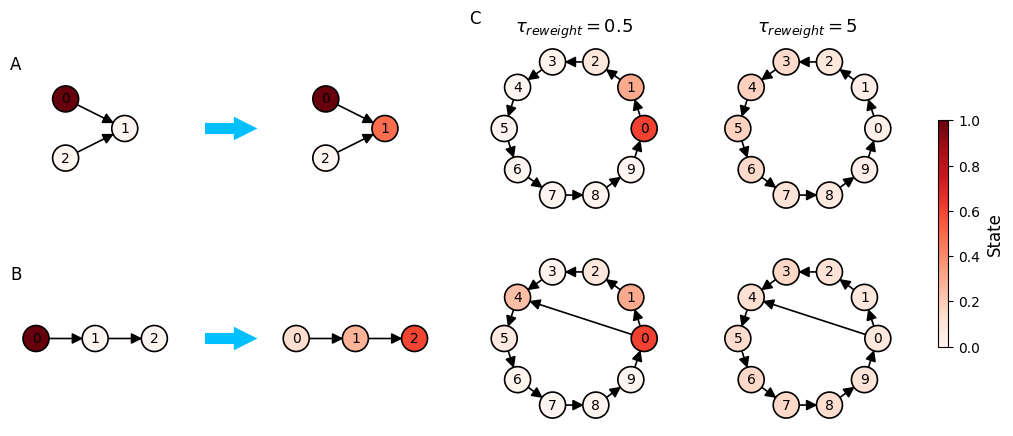

In [5]:
fig = plt.figure(figsize=(12, 5))
gs = fig.add_gridspec(2, 6, width_ratios=[0.8, 0.2, 0.8, 1, 1, 0.05], height_ratios=[1, 1])

ax00 = fig.add_subplot(gs[0, 0]); ax_arrow0 = fig.add_subplot(gs[0, 1]); ax01 = fig.add_subplot(gs[0, 2])
ax10 = fig.add_subplot(gs[1, 0]); ax_arrow1 = fig.add_subplot(gs[1, 1]); ax11 = fig.add_subplot(gs[1, 2])
ax03 = fig.add_subplot(gs[0, 3]); ax04 = fig.add_subplot(gs[0, 4])
ax13 = fig.add_subplot(gs[1, 3]); ax14 = fig.add_subplot(gs[1, 4])

# Fig 3.A
draw.draw_network_state(ax00, G1, nodes, pos1, C_state[tau_ls1[0]])
ax00.set_xlim(-0.3, 2.5)
ax00.set_ylim(-0.9, 0.9)
draw.draw_network_state(ax01, G1, nodes, pos1, C_state[tau_ls1[1]])
ax01.set_xlim(-0.3, 2.5)
ax01.set_ylim(-0.9, 0.9)

ax_arrow0.annotate( "",
    xy=(1.2, 0.5), xytext=(-0.2, 0.5),
    xycoords="axes fraction",
    arrowprops=dict(
        arrowstyle="-|>",
        mutation_scale=10, linewidth=8,
        color="deepskyblue",
        capstyle="butt", joinstyle="miter"))
ax_arrow0.axis("off")

# Fig 3.B
draw.draw_network_state(ax10, G2, nodes, pos2, A_state[tau_ls1[0]])
ax10.set_xlim(-0.3, 2.5)
ax10.set_ylim(-0.9, 0.9)

draw.draw_network_state(ax11, G2, nodes, pos2, A_state[tau_ls1[1]])
ax11.set_xlim(-0.3, 2.5)
ax11.set_ylim(-0.3, 0.3)

ax_arrow1.annotate( "",
    xy=(1.2, 0.5), xytext=(-0.2, 0.5),
    xycoords="axes fraction",
    arrowprops=dict(
        arrowstyle="-|>",
        mutation_scale=10, linewidth=8,
        color="deepskyblue",
        capstyle="butt", joinstyle="miter"))
ax_arrow1.axis("off")

# Fig 3.C
draw.draw_network_state(ax03, RG1, Rnodes, Rpos, C_state_1[tau_ls2[0]], title = "$\\tau_{reweight} = $"+str(tau_ls2[0]))
ax03.set_xlim(-1.25, 1.25)
ax03.set_ylim(-1.25, 1.25)
draw.draw_network_state(ax04, RG1, Rnodes, Rpos, C_state_1[tau_ls2[1]], title = "$\\tau_{reweight} = $"+str(tau_ls2[1]))
ax04.set_xlim(-1.25, 1.25)
ax04.set_ylim(-1.25, 1.25)
draw.draw_network_state(ax13, RG2, Rnodes, Rpos, C_state_2[tau_ls2[0]])
ax13.set_xlim(-1.25, 1.25)
ax13.set_ylim(-1.25, 1.25)
draw.draw_network_state(ax14, RG2, Rnodes, Rpos, C_state_2[tau_ls2[1]])
ax14.set_xlim(-1.25, 1.25)
ax14.set_ylim(-1.25, 1.25)


ax00.text(-0.05, 1.05, 'A', transform=ax00.transAxes, size=12)
ax10.text(-0.05, 1.05, 'B', transform=ax10.transAxes, size=12)
ax03.text(-0.1, 1.1, 'C', transform=ax03.transAxes, size=12)

# Colorbar
cbar_gs = gs[:, 5].subgridspec(3, 1, height_ratios=[0.25, 1.0, 0.25])
cax = fig.add_subplot(cbar_gs[1, 0])
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
sm.set_array([])
cbar = fig.colorbar(sm, cax=cax, shrink=0.8)
cbar.set_label("State", fontsize=12)
#plt.savefig('../fig/Fig 3.svg', dpi = 300)

# Fig S2

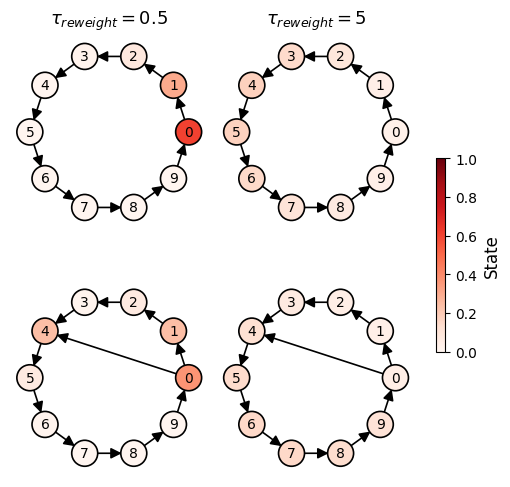

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(5, 5),  constrained_layout=True)

draw.draw_network_state(axes[0, 0], RG1, Rnodes, Rpos, A_state_1[tau_ls2[0]], title = "$\\tau_{reweight} = $"+str(tau_ls2[0]))
axes[0, 0].set_xlim(-1.25, 1.25)
axes[0, 0].set_ylim(-1.25, 1.25)
draw.draw_network_state(axes[0, 1], RG1, Rnodes, Rpos, A_state_1[tau_ls2[1]], title = "$\\tau_{reweight} = $"+str(tau_ls2[1]))
axes[0, 1].set_xlim(-1.25, 1.25)
axes[0, 1].set_ylim(-1.25, 1.25)
draw.draw_network_state(axes[1, 0], RG2, Rnodes, Rpos, A_state_2[tau_ls2[0]])
axes[1, 0].set_xlim(-1.25, 1.25)
axes[1, 0].set_ylim(-1.25, 1.25)
draw.draw_network_state(axes[1, 1], RG2, Rnodes, Rpos, A_state_2[tau_ls2[1]])
axes[1, 1].set_xlim(-1.25, 1.25)
axes[1, 1].set_ylim(-1.25, 1.25)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, shrink=0.4)
cbar.set_label("State", fontsize=12)
#plt.savefig('../fig/Fig S2.svg', dpi = 300)